# Section 27 - Complete Linear Regression 

## 27.12 - Multiple Linear Regression. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [7]:
df_index =  pd.read_csv("economic_index.csv")
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [8]:
df_index.drop(columns=["Unnamed: 0", "year", "month"], inplace=True, axis=1)

In [9]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [10]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

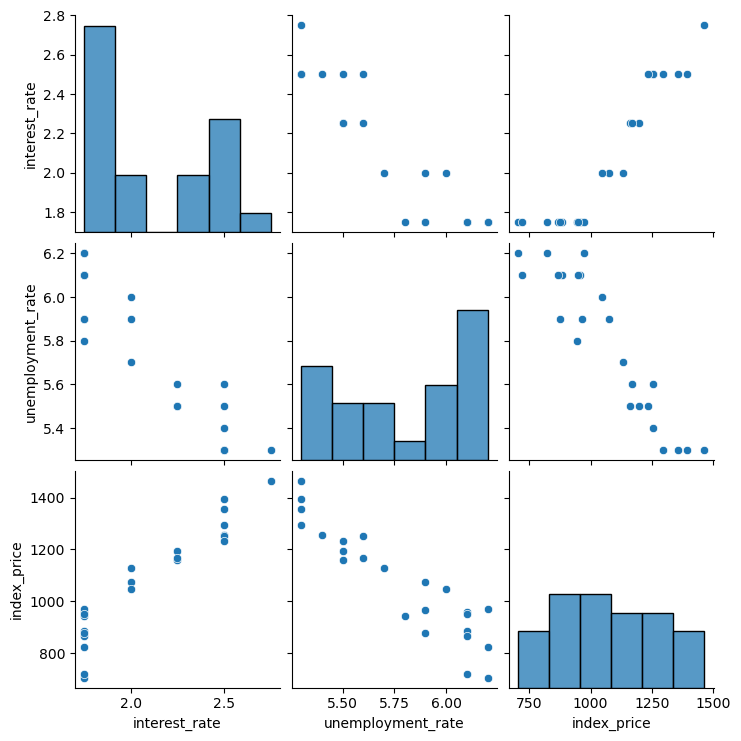

In [11]:
sns.pairplot(df_index)

In [21]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

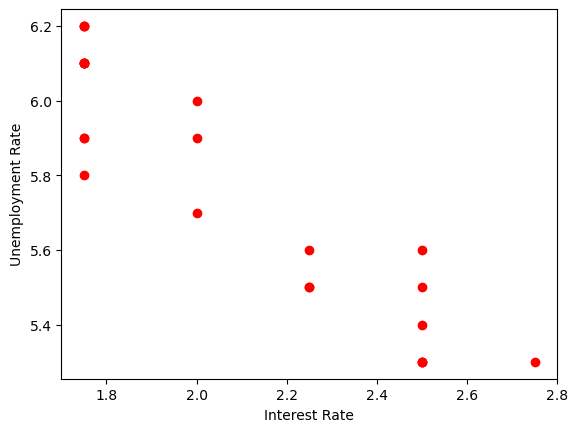

In [22]:
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='r')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')

## Now we get our Independent and Dependent features

In [28]:
# Dependent Feature.
# X = df_index[['intrest_rate','unemployment_rate']]
# Or you can also do this:
X = df_index.iloc[:,:-1]
# It means taking all the features except the last one.

# Independent Feature.
# y = df_index['index_price']
y = df_index.iloc[:,-1]

In [29]:
# Train test split.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

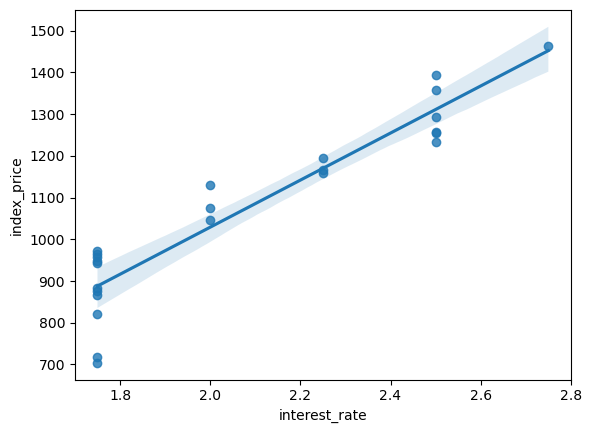

In [33]:
sns.regplot(x=df_index['interest_rate'],y=df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

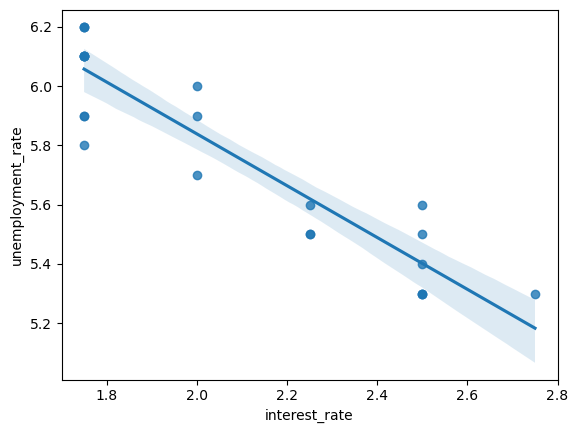

In [35]:
sns.regplot(x=df_index['interest_rate'],y=df_index['unemployment_rate'])

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

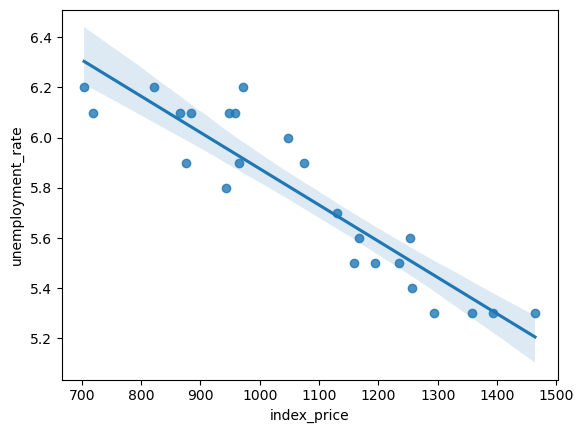

In [37]:
sns.regplot(x=df_index['index_price'],y=df_index['unemployment_rate'])

### Note: this plot can only use for 2 features. 

In [38]:
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [41]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [42]:
regression.fit(X_train, y_train)

LinearRegression()

## Cross Validation Score
- Here we just give our model and X_train and y_train, and this will give me my cross validation.

In [43]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=3)

### cv Explaination
- So we split our model for training and testing, to check the accuracy of the model, right.
- But in cross validation we further divide or training model into train and validation.
- This hyperparameter tunes our model, in simple words it makes our model better.

(To understand the working, refer the handwritten notes.)

In [45]:
np.mean(validation_score)

-5914.828180162388

In [46]:
## Prediction
y_pred = regression.predict(X_test)

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")


Mean Squared Error: 8108.567426306604
Mean Absolute Error: 73.80444932337097
Root Mean Squared Error: 90.04758423359621


In [48]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

# Adjusted R^2 Score
adj_r2 = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(f"Adjusted R^2 Score: {adj_r2}")

R^2 Score: 0.7591371539010257
Adjusted R^2 Score: 0.5985619231683761


### Now We will make some assumptions:

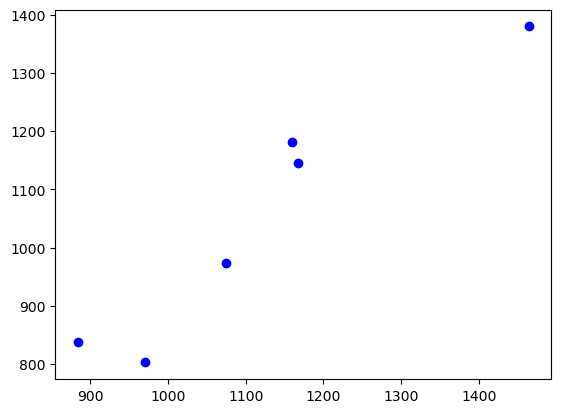

In [49]:
plt.scatter(y_test, y_pred, color='blue')

# Between y_test and y_pred, if there is a linear relationship, that basically means your model has performed well.

In [50]:
# Residuals
residuals = y_test - y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


### These are my errors that we are getting...

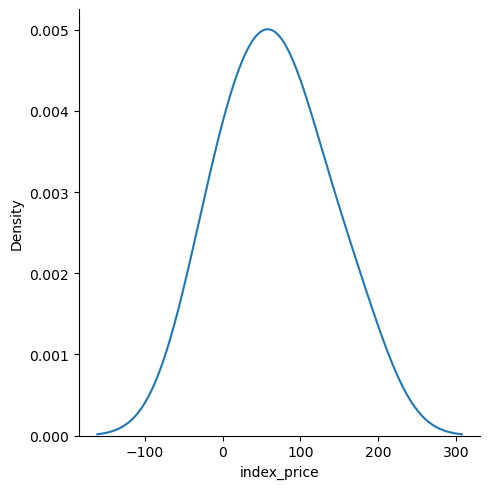

In [52]:
sns.displot(residuals, kind='kde')

# So if we get this kind of curve, the model that we have created is good.

## Now lets create a scatter plot wrt predction and residuals.

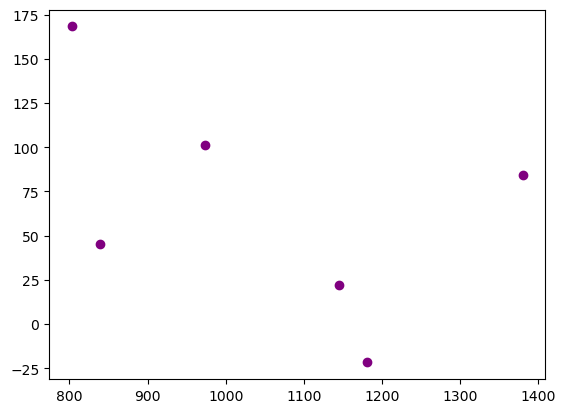

In [53]:
plt.scatter(y_pred, residuals, color='purple')

### Here the data is uniformly distributed, we dont see any patterns. 

# So if your data follow this uniform distribution, then it is good for our model, we can come to a conclusion that our model has no problem in our model.

In [57]:
print(regression.coef_)

[  88.27275507 -116.25716066]


In [58]:
print(regression.intercept_)

1053.4444444444443


## OLS Linear Regression

In [55]:
import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()

In [56]:
model.summary()

c:\Users\OM MAKWANA\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sun, 06 Jul 2025   Prob (F-statistic):                       0.754
Time:                        01:45:09   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""